In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
file_path = "openb_pod_list_cpu0.csv"
data = pd.read_csv(file_path)

print("Dataset Loaded")
print(data.head())


Dataset Loaded
             name  cpu_milli  memory_mib  num_gpu  gpu_milli  gpu_spec qos  \
0  openb-pod-0000      12000       16384        1       1000       NaN  LS   
1  openb-pod-0001       6000       12288        1        460       NaN  LS   
2  openb-pod-0002      12000       24576        1       1000       NaN  LS   
3  openb-pod-0003       6000       12288        1        460       NaN  LS   
4  openb-pod-0004      12000       16384        1       1000       NaN  LS   

  pod_phase  creation_time  deletion_time  scheduled_time  
0   Running              0       12537496             0.0  
1   Running         427061       12902960        427061.0  
2   Running        1558381       12902960       1558381.0  
3   Running        2690044       12902960       2690044.0  
4   Running        2758084       12902960       2758084.0  


In [4]:
# Convert CPU milli to cores
data["cpu_core"] = data["cpu_milli"] / 1000

# Calculate job duration
data["duration"] = data["deletion_time"] - data["creation_time"]

# Remove invalid jobs
data = data[data["duration"] > 0]

print("After preprocessing:")
print(data[["cpu_core", "duration"]].head())


After preprocessing:
   cpu_core  duration
0      12.0  12537496
1       6.0  12475899
2      12.0  11344579
3       6.0  10212916
4      12.0  10144876


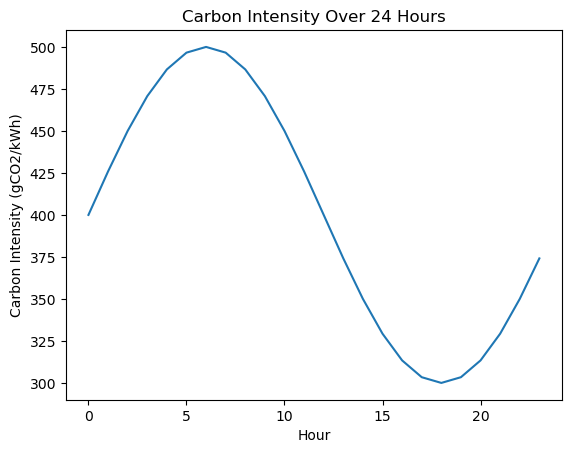

In [5]:
hours = np.arange(24)
carbon_intensity = 400 + 100 * np.sin(2 * np.pi * hours / 24)

carbon_df = pd.DataFrame({
    "hour": hours,
    "carbon_intensity": carbon_intensity
})

plt.figure()
plt.plot(carbon_df["hour"], carbon_df["carbon_intensity"])
plt.xlabel("Hour")
plt.ylabel("Carbon Intensity (gCO2/kWh)")
plt.title("Carbon Intensity Over 24 Hours")
plt.show()


In [6]:
data["hour"] = (data["creation_time"] // 3600) % 24


In [7]:
base_power = 100   # watts
alpha = 50         # watts per CPU core

data["power"] = base_power + alpha * data["cpu_core"]

# Convert energy to kWh
data["energy_kwh"] = (data["power"] * data["duration"]) / (1000 * 3600)


In [8]:
data = data.merge(carbon_df, on="hour", how="left")

data["carbon_emission"] = data["energy_kwh"] * data["carbon_intensity"]

original_total_carbon = data["carbon_emission"].sum()

print("Original Total Carbon:", round(original_total_carbon, 2), "gCO2")


Original Total Carbon: 13490044.88 gCO2


In [9]:
base_temp = 25
beta = 8

data["temperature"] = base_temp + beta * data["cpu_core"]

max_temp = 75
data["thermal_violation"] = data["temperature"] > max_temp

print("Thermal Violations:", data["thermal_violation"].sum())


Thermal Violations: 4440


In [10]:
gamma = 0.02

data["failure_rate"] = np.exp(gamma * data["temperature"])

print("Average Failure Rate:", data["failure_rate"].mean())


Average Failure Rate: 263383.15241191385


In [11]:
lowest_carbon_hour = carbon_df.loc[
    carbon_df["carbon_intensity"].idxmin(), "hour"
]

batch_jobs = data.sample(frac=0.5, random_state=42).copy()

batch_jobs["hour"] = lowest_carbon_hour

batch_jobs = batch_jobs.merge(
    carbon_df,
    on="hour",
    how="left",
    suffixes=("", "_new")
)

batch_jobs["new_carbon"] = (
    batch_jobs["energy_kwh"] *
    batch_jobs["carbon_intensity_new"]
)

optimized_total_carbon = (
    batch_jobs["new_carbon"].sum() +
    data.drop(batch_jobs.index)["carbon_emission"].sum()
)

print("Optimized Total Carbon:", round(optimized_total_carbon, 2), "gCO2")


Optimized Total Carbon: 5087353.88 gCO2


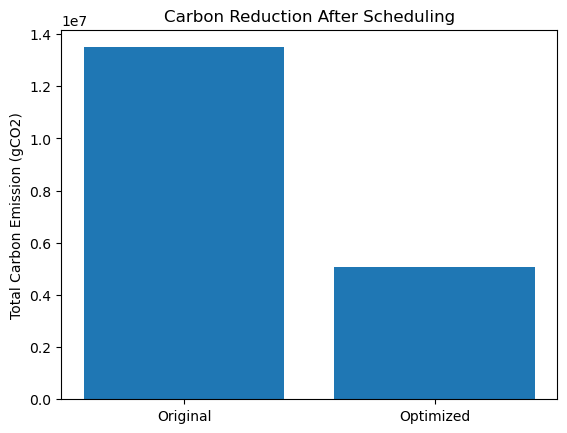

In [12]:
plt.figure()
plt.bar(["Original", "Optimized"],
        [original_total_carbon, optimized_total_carbon])
plt.ylabel("Total Carbon Emission (gCO2)")
plt.title("Carbon Reduction After Scheduling")
plt.show()
